# Model evaluation and plotting

## Import packages and load error data

In [1]:
import os
import glob
import pandas as pd
import numpy as np

# Plotting code
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import matplotlib.font_manager as mfonts
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import seaborn as sns
font = {'family' : 'sans-serif',
        'serif': 'Helvetica Neue',
        'weight' : 'light',
        'size'   : 20}
from scipy.stats import spearmanr, pearsonr

matplotlib.rc('font', **font)
sns.set(style="white")
# Suppress pandas setting with copy warning
pd.options.mode.chained_assignment = None  # default='warn'

In [2]:
available_fonts = [f.name for f in mfonts.fontManager.ttflist]
print([f for f in available_fonts if 'sans' in f.lower()])  # Find sans-serif fonts

['DejaVu Sans', 'DejaVu Sans Mono', 'DejaVu Sans', 'DejaVu Sans Display', 'DejaVu Sans', 'DejaVu Sans Mono', 'DejaVu Sans Mono', 'DejaVu Sans', 'DejaVu Sans Mono', 'Noto Sans Gunjala Gondi', 'Noto Sans Khudawadi', 'Noto Sans Buhid', 'Noto Sans Ugaritic', 'Noto Sans Newa', 'Noto Sans Javanese', 'Noto Sans Bhaiksuki', 'Noto Sans Syriac', 'Noto Sans Meroitic', 'Noto Sans Kayah Li', 'Noto Sans Multani', 'Hiragino Sans', 'Noto Sans Wancho', 'Noto Sans Bassa Vah', 'Noto Sans Cuneiform', 'Noto Sans PhagsPa', 'Noto Sans Mro', 'Noto Sans Linear A', 'Noto Sans Osage', 'Noto Sans Kharoshthi', 'Noto Sans Old South Arabian', 'Noto Sans Kannada', 'Noto Sans Takri', 'Noto Sans Old Turkic', 'Noto Sans Meetei Mayek', 'PT Sans', 'Noto Sans Oriya', 'Noto Sans Hanunoo', 'Noto Sans Egyptian Hieroglyphs', 'Noto Sans Ol Chiki', 'Noto Sans Gothic', 'Noto Sans Tagbanwa', 'Noto Sans Lycian', 'Noto Sans Brahmi', 'Noto Sans Cypriot', 'Noto Sans Rejang', 'Hiragino Sans', 'Noto Sans Vai', 'Hiragino Sans', 'Noto San

In [3]:
# Path to dump figures
figs_path = "../../antigen-tex/figures/"

# Set plotting parameters
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 10,
    'axes.linewidth': 0.8,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'legend.frameon': False
})

# Color palette for the different locations
deme_palette = {
    "tropics": "#3498db",  # Softer blue
    "north": "#e67e22",    # Warmer orange 
    "south": "#2ecc71"     # More vibrant green
}

model_palette = {'FGA': "#3498db",  # Blue
                'NAIVE': "#B30000",  # Red
                'GARW': "#2ecc71",  # Green
                'MLR': "#e67e22"   # Yellow
}  

In [4]:
# Load in error data
# Change this back after obtaining sequence results too
build = "flu-simulated-150k-samples-seq"
error_path = f'../results/{build}/frequency_scores.tsv'
error_df = pd.read_csv(error_path, sep='\t')
error_df.describe()

,lead,variant,MAE,MSE,loglik,total_seq,raw_freq,smoothed_freq,pred_freq,coverage_posterior,coverage_predictive
count,218613.000000,218613.000000,210102.000000,210102.000000,2.186130e+05,218613.000000,146385.000000,210102.000000,218613.000000,178396.000000,178396.000000
mean,-3.161308,14.119243,0.228395,0.131522,-inf,42.315448,0.216375,0.218840,0.300586,0.179724,0.517584
std,206.958488,8.357550,0.281705,0.246339,NaN,252.352193,0.361398,0.277910,0.365967,0.383958,0.499692
min,-365.000000,0.000000,0.000000,0.000000,-inf,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-182.000000,7.000000,0.001457,0.000002,-1.703959e+00,0.000000,0.000000,0.000000,0.000060,0.000000,0.000000
50%,-6.000000,14.000000,0.107706,0.011601,-1.111862e-03,2.000000,0.000000,0.077922,0.092028,0.000000,1.000000
75%,173.000000,21.000000,0.361316,0.130549,0.000000e+00,7.000000,0.333333,0.388137,0.573174,0.000000,1.000000
max,365.000000,29.000000,1.000000,1.000000,0.000000e+00,5474.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [5]:
error_df.head()

,country,model,pivot_date,lead,variant,MAE,MSE,loglik,total_seq,raw_freq,smoothed_freq,pred_freq,date,coverage_posterior,coverage_predictive
0,north,NAIVE,2025-10-01,-234,2,0.250000,0.062500,0.0,2.0,1.0,0.750000,1.0,2025-02-09,NaN,NaN
1,north,NAIVE,2025-10-01,-192,2,0.400000,0.160000,0.0,1.0,1.0,0.600000,1.0,2025-03-23,NaN,NaN
2,north,NAIVE,2025-10-01,-178,2,0.333333,0.111111,-inf,5.0,0.0,0.666667,1.0,2025-04-06,NaN,NaN
3,north,NAIVE,2025-10-01,-171,2,0.400000,0.160000,0.0,0.0,NaN,0.600000,1.0,2025-04-13,NaN,NaN
4,north,NAIVE,2025-10-01,-164,2,0.500000,0.250000,-inf,2.0,0.0,0.500000,1.0,2025-04-20,NaN,NaN


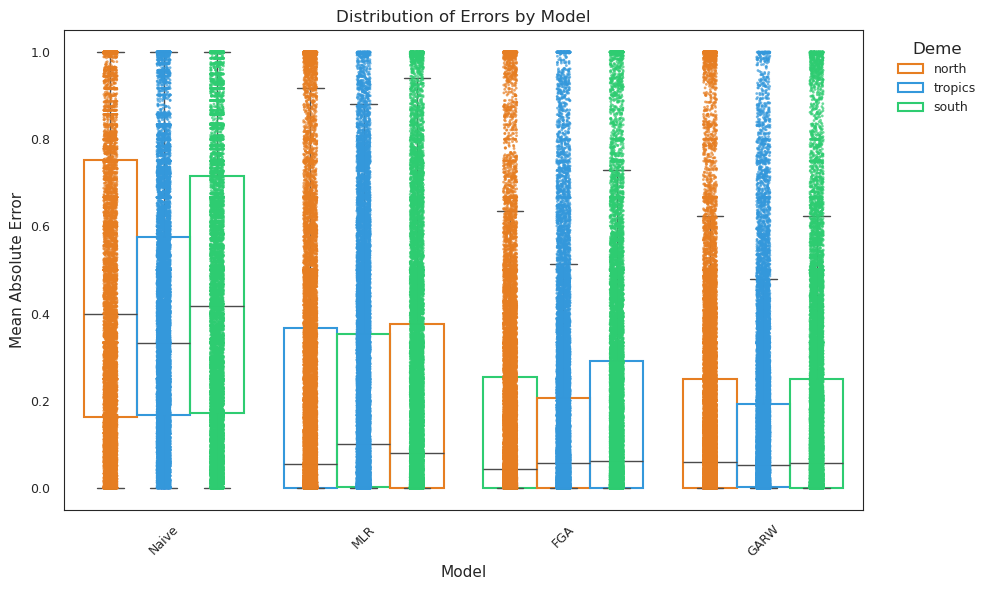

In [ ]:
# Plot the distribution of errors by model
plt.figure(figsize=(10, 6))

# Create a copy of error_df with modified model names
error_df_plot = error_df.copy()
error_df_plot['model'] = error_df_plot['model'].replace({'NAIVE': 'Naive'})

ax = sns.boxplot(data=error_df_plot, 
                 x='model', y='MAE', hue='country', 
                hue_order=['north', 'tropics', 'south'], 
                palette=deme_palette, 
                showfliers=False
            )
# Get the colors from the palette
colors = [deme_palette[deme] for deme in ['north', 'tropics', 'south']]

# Make boxplots transparent and set edge colors
for i, patch in enumerate(ax.patches):
    patch.set_facecolor('none')
    # Set edge color based on which deme it belongs to
    patch.set_edgecolor(colors[i % 3])
    patch.set_linewidth(1.5)  # Make edges more visible

# Overlay swarmplot with individual points
sns.stripplot(data=error_df_plot, x='model', y='MAE',
              hue='country', hue_order=['north', 'tropics', 'south'],palette=deme_palette, 
              dodge=True, jitter=True, size=2, alpha=0.7,
              legend=False  # Avoid duplicate legends
            )
# Customize axes labels and ticks
plt.ylabel('Mean Absolute Error')
plt.xlabel('Model')
plt.title('Distribution of Errors by Model')
plt.xticks(rotation=45)

# Get the legend and change its title
legend = plt.gca().get_legend()
plt.legend(title='Deme', bbox_to_anchor=(1.03, 1), loc='upper left')
plt.tight_layout()


plt.show()

In [ ]:
# Create a multi-panel figure
fig, axes = plt.subplots(1, 3, figsize=(10, 4), constrained_layout=True)

# Panel A: MAE by model and country
sns.boxplot(x='model', y='MAE', data=error_df, hue='country', ax=axes[0], palette=deme_palette, showfliers=False)
axes[0].set_title('A', fontweight='bold', loc='left')
axes[0].set_xlabel('')
axes[0].set_ylabel('Mean Absolute Error')
#axes[0].set_ylim(0, 1.0)
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend().set_visible(False)


# Panel B: MSE by model and country
sns.boxplot(x='model', y='MSE', data=error_df, hue='country', ax=axes[1], palette=deme_palette, showfliers=False)
axes[1].set_title('B', fontweight='bold', loc='left')
axes[1].set_xlabel('')
axes[1].set_ylabel('Mean Squared Error')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend().set_visible(False)

# Panel C: Log-likelihood by model and country
sns.boxplot(x='model', y='loglik', data=error_df, hue='country', ax=axes[2], palette=deme_palette, showfliers=False)
axes[2].set_title('C', fontweight='bold', loc='left')
axes[2].set_xlabel('')
axes[2].set_ylabel('Log Likelihood')
axes[2].tick_params(axis='x', rotation=45)

# Better legend styling
handles, labels = axes[2].get_legend_handles_labels()
legend = plt.legend(
    handles,
    labels,
    bbox_to_anchor=(1.05, 1), 
    loc='upper left', 
    title="Deme",
    frameon=True,
    framealpha=0.95,
    edgecolor='lightgray',
    title_fontsize=12
)

plt.savefig(figs_path + "model_freq_performance_no_outliers.pdf", dpi=300, bbox_inches='tight')
plt.show()

## Distribution of frequency errors across various lead times

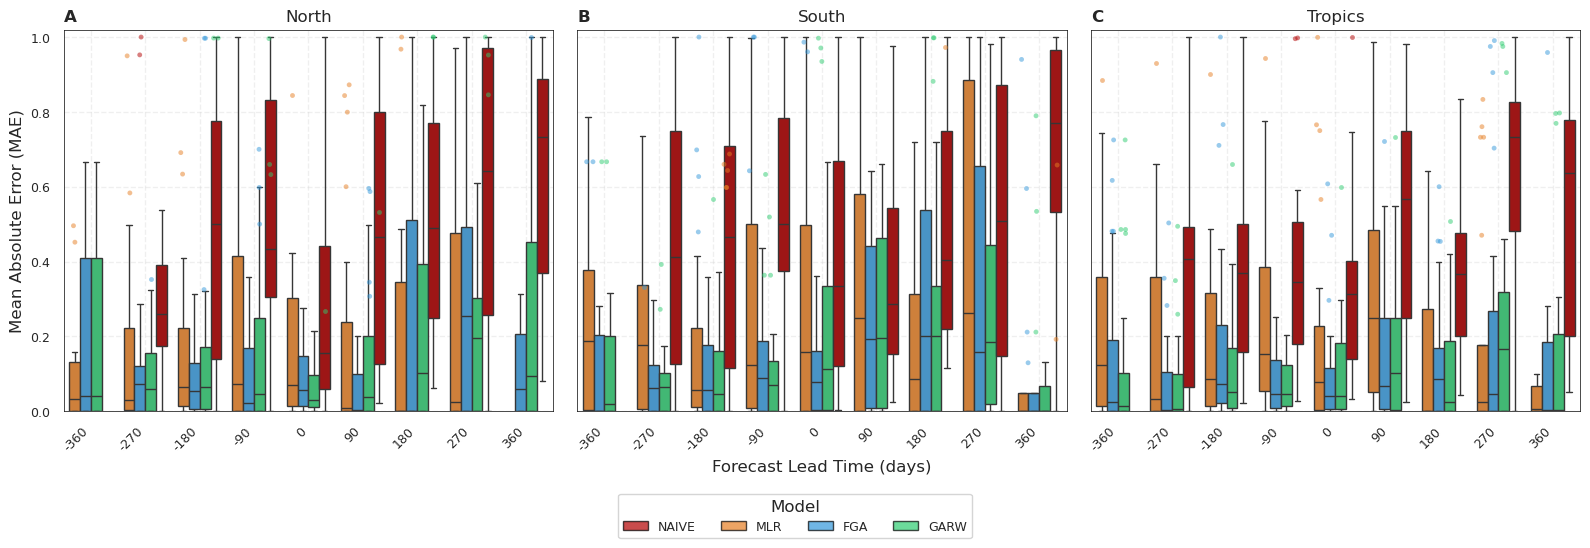

In [8]:
# Define the lead days of interest (quarterly intervals)
lead_days_of_interest = [-360, -270, -180, -90, 0, 90, 180, 270, 360]

# Filter the dataframe to include only the lead days of interest
filtered_df = error_df[error_df['lead'].isin(lead_days_of_interest)]

# Create a figure with subplots for each country arranged horizontally
countries = error_df['country'].unique()
fig, axes = plt.subplots(1, len(countries), figsize=(16, 5.5), sharey=True)

# Ensure axes is always treated as an array
if len(countries) == 1:
    axes = [axes]

# Panel labels
panel_labels = ['A', 'B', 'C']

# Loop through each country
for i, country in enumerate(countries):
    # Get data for this country
    country_df = filtered_df[filtered_df['country'] == country]
    
    # First create the boxplot without outliers
    sns.boxplot(
        data=country_df,
        x='lead',
        y='MAE',
        hue='model',
        palette=model_palette,
        ax=axes[i],
        showfliers=False  # Don't show outliers in boxplot
    )
    
    # Create a dataframe with only outliers
    outlier_df = pd.DataFrame()
    
    # For each model and lead time combination, identify outliers
    for model in country_df['model'].unique():
        for lead in lead_days_of_interest:
            subset = country_df[(country_df['model'] == model) & (country_df['lead'] == lead)]
            
            # Calculate Q1, Q3 and IQR
            q1 = subset['MAE'].quantile(0.25)
            q3 = subset['MAE'].quantile(0.75)
            iqr = q3 - q1
            
            # Define outliers
            upper_bound = q3 + 1.5 * iqr
            
            # Get outliers for this group
            outliers = subset[subset['MAE'] > upper_bound]
            
            # Append to outlier dataframe
            outlier_df = pd.concat([outlier_df, outliers])
    
    # Now plot only the outliers using stripplot
    if not outlier_df.empty:
        sns.stripplot(
            data=outlier_df,
            x='lead',
            y='MAE',
            hue='model',
            palette=model_palette,
            ax=axes[i],
            dodge=True,  # Align with boxplot positions
            size=3.5,  # Smaller points
            alpha=0.5,  # Semi-transparent
            jitter=0.2,  # Add some jitter to avoid overplotting
            legend=False  # Don't add a second legend
        )
    
    # Customize the plot
    # Add panel label (A, B, C) and country name in the title
    axes[i].set_title(f'{panel_labels[i]}', fontweight='bold', loc='left')
    axes[i].set_title(f'{country.capitalize()}', fontweight='normal', loc='center')
    axes[i].grid(True, linestyle='--', alpha=0.3)
    axes[i].set_ylim(0, 1.02)  # Cap at 1.0 for better focus on main distribution
    
    # Only show legend for the first subplot
    if i > 0:
        axes[i].get_legend().remove()
    else:
        axes[i].get_legend().set_visible(False)  # Remove all subplot legends
    
    # Add thin borders
    for spine in axes[i].spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(0.5)
    
    # Get current tick positions that seaborn has created
    tick_positions = axes[i].get_xticks()
    
    # Set tick positions explicitly, then set labels
    axes[i].set_xticks(tick_positions)
    
    # Set x-axis label only for the middle subplot
    if i == len(countries) // 2:  # Middle panel
        axes[i].set_xlabel('Forecast Lead Time (days)', fontsize=12)
    else:
        axes[i].set_xlabel('')  # Remove x-axis label for other panels
    axes[i].set_xticklabels([str(x) for x in lead_days_of_interest], rotation=45, ha='right')
    
    # Add y-axis label only for the first subplot
    if i == 0:
        axes[i].set_ylabel('Mean Absolute Error (MAE)', fontsize=12)
    else:
        axes[i].set_ylabel('')

# Add legend at the bottom center
legend_elements = []
for model in country_df['model'].unique():
    box = mpatches.Patch(facecolor=model_palette[model], edgecolor='black',
                        alpha=0.7, label=model)
    legend_elements.append(box)

fig.legend(
    legend_elements,
    country_df['model'].unique(),
    ncol=4,
    bbox_to_anchor=(0.5, -0.02),
    loc="lower center",
    title="Model",
    frameon=True,
    framealpha=0.95,
    edgecolor='lightgray',
    title_fontsize=12
)

# Adjust the layout
plt.tight_layout(rect=[0, 0.08, 1, 0.98])
# Save the figure
plt.savefig(figs_path + "model_freq_performance_by_lead.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Read in fitness dataframe
fitness_path = f'../data/{build}/antigen-outputs/pruned_variant_fitness.csv'
fitness_df = pd.read_csv(fitness_path)
fitness_df['date'] = pd.to_datetime(fitness_df['date'])
fitness_df.head()

In [ ]:
ref_variants_path = f"../data/{build}/clades/ref_variants.tsv"
ref_variants_df = pd.read_csv(ref_variants_path, sep='\t')
ref_variants_df.rename(columns={'country': 'location', 'ref_variant': 'variant', 'timepoint': 'pivot_date'}, inplace=True)
# Just add dummy columns for model and median_ga, ga_upper_95, ga_lower_95, ga_upper_80, ga_lower_80, ga_upper_50, ga_lower_50
ref_variants_df['model'] = 'MLR'
ref_variants_df['median_ga'] = 1.0
ref_variants_df['ga_upper_95'] = 1.0
ref_variants_df['ga_lower_95'] = 1.0
ref_variants_df['ga_upper_80'] = 1.0
ref_variants_df['ga_lower_80'] = 1.0
ref_variants_df['ga_upper_50'] = 1.0
ref_variants_df['ga_lower_50'] = 1.0
ref_variants_df.head()
ref_variants_df.head()

In [ ]:
rt_paths = glob.glob(f"../results/{build}/estimates/*/rt_*.tsv")
rt_dfs = []
for rt_path in rt_paths:
    rt_df = pd.read_csv(rt_path, sep='\t')
    # Parse date from file path
    date = rt_path.split("/")[-1].split("_")[-1].split(".")[0]
    rt_df['pivot_date'] = date
    rt_dfs.append(rt_df)
rt_df = pd.concat(rt_dfs)
rt_df.head()

### Small example of scoring a single $R_v(t)$ window

In [ ]:
def get_fitness_ranks_for_window(mini_df):
    """ Get fitness ranks for a given window of data. There should only be a single 'fitness_date' in the df.
    
    Parameters
    ----------
    mini_df : pd.DataFrame
        A DataFrame containing the fitness and rt data for a single window of time, typically between fitness sample dates.

    Returns
    -------
    variant_ranks : pd.DataFrame
        A DataFrame containing the fitness ranks for the variants in the window.
    """
    # Rank variants by fitness
    mini_df['fitness_rank'] = mini_df['fitness'].rank(method='dense', ascending=False)
    # Now just grab unique variants and their fitness ranks
    unique_variants = mini_df.drop_duplicates(subset=['variant'])
    variant_ranks = unique_variants[['variant', 'fitness', 'fitness_rank', 'fitness_date']]
    return variant_ranks

In [ ]:
def get_rt_ranks_for_window(mini_df):
    """ Get rt ranks for a given window of data. There should only be a single 'rt_date' in the df.
    
    Parameters
    ----------
    mini_df : pd.DataFrame
        A DataFrame containing the fitness and rt data for a single window of time, typically between fitness sample dates.

    Returns
    -------
    variant_ranks : pd.DataFrame
        A DataFrame containing the rt ranks for the variants in the window.
    """
    # Rank variants by rt
    mini_df['rt_rank'] = mini_df['median_R'].rank(method='dense', ascending=False)
    # Now just grab unique variants and their rt ranks
    unique_variants = mini_df.drop_duplicates(subset=['variant'])
    variant_ranks = unique_variants[['variant', 'median_R', 'rt_rank', 'rt_date', 'lead']]
    return variant_ranks


In [ ]:
def calculate_rank_correlation_for_fitness_window(mini_df):
    """ Calculate the rank correlation between fitness and rt for a given window of data.
    
    Parameters
    ----------
    mini_df : pd.DataFrame
        A DataFrame containing the fitness and rt data for a single window of time, typically between fitness sample dates.

    Returns
    -------
    pd.DataFrame
        Dataframe containing the rank correlation between fitness and rt for each date in the window.
    """
    # Now, loop through each rt_date in the mini_df and calculate the rank correlation between fitness and rt
    results = []
    for rt_date in mini_df['rt_date'].unique():
        day_df = mini_df[mini_df['rt_date'] == rt_date]
        # Grab relevant metadata for results dataframe
        lead = day_df['lead'].unique()[0]
        model = day_df['model'].unique()[0]
        location = day_df['location'].unique()[0]
        
        # Calculate variant ranks for fitness and rt and calculate the rank correlation
        fitness_ranks = get_fitness_ranks_for_window(day_df)
        rt_ranks = get_rt_ranks_for_window(day_df)
        merged_ranks = fitness_ranks.merge(rt_ranks, on='variant', how='inner')
        correlation, _ = spearmanr(merged_ranks['fitness_rank'], merged_ranks['rt_rank'])
        
        # Store the results
        results.append({
            'date': rt_date,
            'location': location,
            'model': model,
            'lead': lead,
            'correlation': correlation
        })

    return pd.DataFrame(results)

In [ ]:
def merge_fitness_and_rt_dfs(rt_df, fitness_df):
    """ Merge fitness and rt dataframes to create a single dataframe for analysis.
    
    Parameters
    ----------
    rt_df : pd.DataFrame
        A DataFrame containing the rt data.
    fitness_df : pd.DataFrame
        A DataFrame containing the fitness data.
    
    Returns
    -------
    merged_dfs : list
        A list of DataFrames containing the merged fitness and rt data.
    """
    rt_df['date'] = pd.to_datetime(rt_df['date'])
    fitness_df['date'] = pd.to_datetime(fitness_df['date'])
    # Get all of the dates available in the fitness df and sort in ascending order
    fitness_dates = fitness_df['date'].unique()
    fitness_dates.sort()

    merged_dfs = []
    # Loop through each date in the fitness df, subset the rt data to only include data from that 
    for i in range(0, len(fitness_dates)):
        # First entry
        if i == 0:
            subset_rt_df = rt_df[(rt_df['date'] <= fitness_dates[i])]
            subset_fitness_df = fitness_df[(fitness_df['date'] <= fitness_dates[i])]
        else:
            subset_rt_df = rt_df[(rt_df['date'] > fitness_dates[i-1]) & (rt_df['date'] <= fitness_dates[i])]
            subset_fitness_df = fitness_df[(fitness_df['date'] > fitness_dates[i-1]) & (fitness_df['date'] <= fitness_dates[i])]
        # Rename the date columns for merge
        subset_rt_df.rename(columns={'date': 'rt_date'}, inplace=True)
        subset_fitness_df.rename(columns={'date': 'fitness_date'}, inplace=True)
        merged_fitness_df = subset_rt_df.merge(subset_fitness_df, on=['variant', 'location'], how='inner')
        # Drop all columns with 'forecast' in the name
        merged_fitness_df = merged_fitness_df[merged_fitness_df.columns.drop(list(merged_fitness_df.filter(regex='forecast')))]
        merged_dfs.append(merged_fitness_df)
    
    return merged_dfs

In [ ]:
def prep_fitness_and_rt_dfs(rt_df, fitness_df):
    """ Prepare fitness and rt dataframes for rank correlation analysis.
    
    Parameters
    ----------
    rt_df : pd.DataFrame
        A DataFrame containing the rt estimates for each variant.
    fitness_df : pd.DataFrame
        A DataFrame containing the fitness estimates for each variant.

    Returns
    -------
    rt_df_new : pd.DataFrame
        TBD
    fitness_df_new : pd.DataFrame
        TBD
    """
    rt_df = rt_df[rt_df.columns.drop(list(rt_df.filter(regex='forecast')))]
    # Drop any rows with missing data
    rt_df = rt_df.dropna(subset=['median_R'])
    min_date = pd.to_datetime(rt_df['date']).min()
    max_date = pd.to_datetime(rt_df['date']).max()
    deme = rt_df['location'].unique()[0]
    rt_df['date'] = pd.to_datetime(rt_df['date'])
    rt_df['pivot_date'] = pd.to_datetime(rt_df['pivot_date'])
    rt_df['lead'] = (rt_df['date'] - rt_df['pivot_date']).dt.days
    
    # Subset fitness data to only include data within the range of the rt data
    fitness_df_new = fitness_df[(fitness_df['date'] >= min_date) & (fitness_df['date'] <= max_date) & (fitness_df['location'] == deme)]
    fitness_df_new = fitness_df_new.dropna(subset=['fitness'])

    return rt_df, fitness_df_new

## Pearson Correlation across all training windows

In [ ]:
results_df = {
    'pivot_date': [],
    'location': [],
    'variant': [],
    'model': [],
    'correlation': []
}
for rt_df in rt_dfs:
    rt_df['date'] = pd.to_datetime(rt_df['date'])
    rt_df['pivot_date'] = pd.to_datetime(rt_df['pivot_date'])
    # Get window of fitness data
    rt_window_df, fitness_window_df = prep_fitness_and_rt_dfs(rt_df, fitness_df)
    # Merge dataframes
    merged_df = pd.merge(fitness_window_df, rt_window_df, on=['variant', 'location', 'date'], how='inner')

    # Now calculate spearman correlation for each variant
    for variant in merged_df['variant'].unique():
        variant_df = merged_df.query(f"variant == {variant}")
        # Sort by t column in ascending order
        variant_df = variant_df.sort_values(by='t')
        # Calculate the correlation between fitness and rt
        correlation, _ = pearsonr(variant_df['fitness'], variant_df['median_R'])
        results_df['pivot_date'].append(variant_df['pivot_date'].unique()[0])
        results_df['location'].append(variant_df['location'].unique()[0])
        results_df['variant'].append(variant)
        results_df['model'].append(variant_df['model'].unique()[0])
        results_df['correlation'].append(correlation)
results_df = pd.DataFrame(results_df)
results_df.head()

In [ ]:
# Write results to file
fitness_rt_pearson_path = f'../results/{build}/fitness_rt_pearson.tsv'
results_df.to_csv(fitness_rt_pearson_path, sep='\t', index=False)

In [ ]:
# Plot distribution of correlation values by model
plt.figure(figsize=(12, 8))
# Density plot of correlation values
sns.kdeplot(data=results_df, x='correlation', hue='model', fill=True)
plt.xlabel('Pearson Correlation')
plt.ylabel('Density')
plt.title(r'Distribution of Pearson Correlation Values between Fitness and $R_t$', fontsize=16)
plt.xlim(-1, 1)
plt.show()

In [ ]:
# For each pivot-date, location, and model, return the average correlation value across all variants
grouped = results_df.groupby(['pivot_date', 'location', 'model'])
average_correlations = []
for (pivot_date, location, model), group in grouped:
    average_correlation = group['correlation'].mean()
    worst_correlation = group['correlation'].min()
    average_correlations.append({
        'pivot_date': pivot_date,
        'location': location,
        'model': model,
        'average_correlation': average_correlation,
        'worst_correlation': worst_correlation
    })
average_correlations_df = pd.DataFrame(average_correlations)

In [ ]:
average_correlations_df.describe()

In [ ]:
# Plot side-by-side plots of the average and worst correlation values by model
# Create two subplots
fig, axs = plt.subplots(1, 2, figsize=(16, 8), sharey=True)
# Density plot of average correlation values
sns.kdeplot(data=average_correlations_df, x='average_correlation', hue='model', fill=True, ax=axs[0])
axs[0].set_xlabel('Average Pearson Correlation')
axs[0].set_ylabel('Density')
axs[0].set_xlim(-1, 1)
sns.kdeplot(data=average_correlations_df, x='worst_correlation', hue='model', fill=True, ax=axs[1])
axs[1].set_xlabel('Worst Pearson Correlation')
axs[1].set_xlim(-1, 1)

plt.show()


In [ ]:
# Create boxplot of average correlation values by model
plt.figure(figsize=(12, 8))
sns.boxplot(data=average_correlations_df, x='model', y='average_correlation')
plt.xlabel('Model')
plt.show()

In [ ]:
plt.figure(figsize=(12, 8))
sns.boxplot(data=average_correlations_df, x='model', y='worst_correlation')
plt.xlabel('Model')
plt.show()

In [ ]:
# Create a lineplot of average correlation values by pivot_date
plt.figure(figsize=(18, 6))
sns.stripplot(data=average_correlations_df, x='pivot_date', y='average_correlation', hue='location', size=6, edgecolor='black', linewidth=0.5)
plt.xlabel('Pivot Date')
plt.ylabel('Average Pearson Correlation')
# Pivot x axis ticks to 90 degrees
plt.xticks(rotation=90)
# Add horizontal line at 0
plt.axhline(-0.75, color='red', linestyle='--')
# Move legend outside to the right of the plot
plt.legend(loc='center left', bbox_to_anchor=(1, 0.85))
plt.title(r'Average Pearson Correlation between Fitness and $R_t$ by Pivot Date', fontsize=16)
plt.show()

In [ ]:
rank_list = []
for rt_df in rt_dfs:
    print(f"Processing {rt_df['location'].unique()[0]}, {rt_df['pivot_date'].unique()[0]}")
    window_rt_df, window_fitness_df = prep_fitness_and_rt_dfs(rt_df, fitness_df)
    test_date_list = merge_fitness_and_rt_dfs(window_rt_df, window_fitness_df)
    for test_date_df in test_date_list:
        rank_df = calculate_rank_correlation_for_fitness_window(test_date_df)
        rank_list.append(rank_df)
rank_df = pd.concat(rank_list)

In [ ]:
rank_df.head()

In [ ]:
# Plot a boxplot of MAE by model
fig = plt.figure(figsize=(12, 5))
query_condition = "lead == -365 or lead == -180 or lead == -120 or lead == -150 or lead == -90 or lead == -60 or lead == -30"
sns.boxplot(data=rank_df.query(query_condition).reset_index(), x='lead', y='correlation', hue='model')
plt.title(r'Rank correlation between fitness and $R_v(t)$ by lead time')
plt.xlabel('Lead time (days)')
plt.ylabel('Correlation')
plt.ylim(-1, 1.05)
plt.legend(title='Model', loc='upper left', bbox_to_anchor=(1, 1))
#plt.savefig(base_path + "mae_boxplot.pdf", bbox_inches='tight')
plt.show()

In [ ]:
rank_dfs = []
for mini_df in test_list:
    # Debug this -- seems like nothing is being added to the rank_dfs
    rank_dfs.append(calculate_rank_correlation_for_fitness_window(mini_df))
rank_df = pd.concat(rank_dfs)
rank_df.head()

In [ ]:
get_fitness_ranks_for_window(tmp)

In [ ]:
# Get all of the dates available in the fitness df and sort in ascending order
fitness_dates = fitness_test_df['date'].unique()
fitness_dates.sort()

merged_dfs = []
# Loop through each date in the fitness df, subset the rt data to only include data from that 
for i in range(0, len(fitness_dates)):
    # First entry
    if i == 0:
        subset_rt_df = test_rt_df[(test_rt_df['date'] <= fitness_dates[i])]
        subset_fitness_df = fitness_test_df[(fitness_test_df['date'] <= fitness_dates[i])]
    else:
        subset_rt_df = test_rt_df[(test_rt_df['date'] > fitness_dates[i-1]) & (test_rt_df['date'] <= fitness_dates[i])]
        subset_fitness_df = fitness_test_df[(fitness_test_df['date'] > fitness_dates[i-1]) & (fitness_test_df['date'] <= fitness_dates[i])]
    # Rename the date columns for merge
    subset_rt_df.rename(columns={'date': 'rt_date'}, inplace=True)
    subset_fitness_df.rename(columns={'date': 'fitness_date'}, inplace=True)
    merged_fitness_df = subset_rt_df.merge(subset_fitness_df, on=['variant', 'location'], how='inner')
    # Drop all columns with 'forecast' in the name
    merged_fitness_df = merged_fitness_df[merged_fitness_df.columns.drop(list(merged_fitness_df.filter(regex='forecast')))]
    merged_dfs.append(merged_fitness_df)

In [ ]:
mini_df = merged_dfs[0]
mini_df.head()

In [ ]:
get_fitness_ranks_for_window(mini_df)

In [ ]:
# Subset mini_df to only include the first date
day_df = mini_df[mini_df['rt_date'] == mini_df['rt_date'].min()]

get_rt_ranks_for_window(day_df)

In [ ]:
# For duplicate rows, we will take the mean of the estimates
rt_df_unique = rt_df.groupby(['date', 'pivot_date', 'location', 'variant', 'model']).mean().reset_index()
rt_df_unique.head()

In [ ]:
# Create merged fitness dataframe
rt_df_unique['date'] = pd.to_datetime(rt_df_unique['date'])

merged_fitness_df = rt_df_unique.merge(fitness_df, on=['date', 'variant', 'location'], how='inner')
merged_fitness_df.head()

In [ ]:
# Plot a boxplot of MAE by model
fig = plt.figure(figsize=(12, 5))
query_condition = "lead == -365 or lead == -180 or lead == -120 or lead == -90 or lead == -30 or lead == 0 or lead == 30 or lead == 60 or lead == 90 or lead == 120 or lead == 180"
sns.boxplot(data=error_df.query(query_condition), x='lead', y='MAE', hue='model')
plt.title('Absolute error of frequency predictions')
plt.xlabel('Lead time (days)')
plt.ylabel('Error')
plt.ylim(0, 1.05)
plt.legend(title='Model', loc='upper left', bbox_to_anchor=(1, 1))
#plt.savefig(base_path + "mae_boxplot.pdf", bbox_inches='tight')
plt.show()

## Dive into nowcast errors

In [ ]:
# Get longcast, nowcast, and forecast errors:
longpast_df = error_df.query('lead < 0')
nowcast_df = error_df.query('lead > -120 & lead <= 0')
forecast_df = error_df.query('lead > 0')

In [ ]:
# Get all rows with lead = 0 and group by model
longpast_df = longpast_df.groupby(['model', 'country', 'pivot_date'])['MAE'].mean().reset_index()
nowcast_df = nowcast_df.groupby(['model', 'country', 'pivot_date'])['MAE'].mean().reset_index()
forecast_df = forecast_df.groupby(['model', 'country', 'pivot_date'])['MAE'].mean().reset_index()

In [ ]:
longpast_df['forecast_type'] = 'pastcast'
nowcast_df['forecast_type'] = 'nowcast'
forecast_df['forecast_type'] = 'forecast'

# Combine all errors
all_errors_df = pd.concat([longpast_df, nowcast_df, forecast_df], axis=0)
all_errors_df.head()

## GARW model nowcast distributions

In [ ]:
garw_df = all_errors_df.query("model == 'GARW'").reset_index(drop=True)
garw_df.head()

In [ ]:
# Boxplot of MAE by model
plt.figure(figsize=(20, 6))
# Sort garw_df by date
garw_df = garw_df.sort_values(['pivot_date', 'country'])
future_df = garw_df.query("forecast_type == 'forecast'")
sns.scatterplot(data=future_df, x='pivot_date', y='MAE', hue='country', s=100)

# Add outline to points with MAE > 0.5
outliers = future_df.query('MAE > 0.5')
for i, row in outliers.iterrows():
    plt.text(row['pivot_date'], row['MAE'], '*', fontsize=20, color='black', ha='left', va='bottom')

plt.xlabel('Analysis Date')
plt.title('Average MAE of GARW forecasts')
plt.xticks(rotation=90)
plt.xticks(fontsize=16)
plt.ylim(-0.02, 1.1)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.4), ncol=3)
plt.show()

In [ ]:
# Plot nowcasts errors
plt.figure(figsize=(20, 6))
present_df = garw_df.query("forecast_type == 'nowcast'")
sns.scatterplot(data=present_df, x='pivot_date', y='MAE', hue='country', s=100)

# Add outline to points with MAE > 0.5
outliers = present_df.query('MAE > 0.5')
for i, row in outliers.iterrows():
    plt.text(row['pivot_date'], row['MAE'], '*', fontsize=20, color='black', ha='left', va='bottom')

plt.xlabel('Analysis Date')
plt.title('Average MAE of GARW nowcasts')
plt.xticks(rotation=90)
plt.xticks(fontsize=16)
plt.ylim(-0.02, 1.1)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.4), ncol=3)
plt.show()

In [ ]:
plt.figure(figsize=(20, 6))
# Get pastcasts
past_df = garw_df.query("forecast_type == 'pastcast'")
sns.scatterplot(data=past_df, x='pivot_date', y='MAE', hue='country', s=100)

# Add outline to points with MAE > 0.5
outliers = past_df.query('MAE > 0.5')
for i, row in outliers.iterrows():
    plt.text(row['pivot_date'], row['MAE'], '*', fontsize=20, color='black', ha='left', va='bottom')

plt.xlabel('Analysis Date')
plt.title('Average MAE of GARW pastcasts')
plt.xticks(rotation=90)
plt.xticks(fontsize=16)
plt.ylim(-0.02, 1.1)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.4), ncol=3)
plt.show()

## Look at fitness errors

In [ ]:
corr_df, details_df = calculate_rank_correlation(merged_fitness_df)
corr_df.head()

In [ ]:
# Create a lineplot of the correlation column from corr_df
fig, ax = plt.subplots(figsize=(20, 5))
model = 'GARW'
model_df = corr_df.query(f'model == "{model}"')
sns.scatterplot(data=model_df, x='pivot_date', y='correlation', hue='location', style='location', s=100, ax=ax)
ax.set_title(rf"Fitness and $R_v(t)$ agreement for {model} models")
outliers = model_df.query('correlation < -0.8')
for i, row in outliers.iterrows():
    plt.text(row['pivot_date'], row['correlation'], '*', fontsize=20, color='black', ha='center', va='bottom')
ax.set_xlabel("Date")
# Rotate x-axis labels
plt.xticks(rotation=90)
# Change font size of x-axis labels
plt.xticks(fontsize=16)
ax.set_ylabel(r"Spearman $\rho$")
# Add a horizontal line at 0
ax.axhline(y=0, color='red', linestyle='--', lw=2.5)
# Move legend outside of plot
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1.0), ncol=1)
plt.show()

In [ ]:
# Create a lineplot of the correlation column from corr_df
fig, ax = plt.subplots(figsize=(20, 5))
model = 'FGA'
model_df = corr_df.query(f'model == "{model}"')
sns.scatterplot(data=model_df, x='pivot_date', y='correlation', hue='location', style='location', s=100, ax=ax)
ax.set_title(rf"Fitness and $R_v(t)$ agreement for {model} models")
outliers = model_df.query('correlation < -0.8')
for i, row in outliers.iterrows():
    plt.text(row['pivot_date'], row['correlation'], '*', fontsize=20, color='black', ha='center', va='bottom')
ax.set_xlabel("Date")
# Rotate x-axis labels
plt.xticks(rotation=90)
# Change font size of x-axis labels
plt.xticks(fontsize=16)
ax.set_ylabel(r"Spearman $\rho$")
# Add a horizontal line at 0
ax.axhline(y=0, color='red', linestyle='--', lw=2.5)
# Move legend outside of plot
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1.0), ncol=1)
plt.show()

In [ ]:
# We need to grab the rest of the dates
merged_ga_df = ga_df_unique.merge(fitness_df, on=['date', 'variant', 'location'], how='inner')
merged_ga_df.head()

In [ ]:
corr_ga_df, details_ga_df = calculate_rank_correlation(merged_ga_df, site='ga')
corr_ga_df.head()

In [ ]:
# Create a lineplot of the correlation column from corr_df
fig, ax = plt.subplots(figsize=(20, 5))
model = 'MLR'
sns.scatterplot(data=corr_ga_df, x='pivot_date', y='correlation', hue='location', s=100, ax=ax)
ax.set_title(rf"Fitness and $R_v(t)$ agreement for {model} models")
outliers = corr_ga_df.query('correlation < -0.8')
for i, row in outliers.iterrows():
    plt.text(row['pivot_date'], row['correlation'], '*', fontsize=20, color='black', ha='center', va='bottom')
ax.set_xlabel("Date")
# Rotate x-axis labels
plt.xticks(rotation=90)
# Change font size of x-axis labels
plt.xticks(fontsize=16)
ax.set_ylabel(r"Spearman $\rho$")
# Add a horizontal line at 0
ax.axhline(y=0, color='red', linestyle='--', lw=2.5)
# Move legend outside of plot
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1.0), ncol=1)
plt.show()

## Grab error outliers for future analysis

In [ ]:
all_errors_df.head()

In [ ]:
outlier_df = all_errors_df.query('MAE > 0.5')
outlier_df.head()

## Look at distributions of errors

In [ ]:
mae_df = error_df.groupby(['lead', 'country', 'model'])['MAE'].quantile([0.25, 0.5, 0.75]).unstack().reset_index()
mae_df.rename(columns={0.25: 'q25', 0.5: 'median', 0.75: 'q75'}, inplace=True)
mae_df.head()

In [ ]:
mse_df = error_df.groupby(['lead', 'country', 'model'])['MSE'].mean().reset_index()
#mse_df.rename(columns={0.25: 'q25', 0.5: 'median', 0.75: 'q75'}, inplace=True)
mse_df.head()

In [ ]:
# Define the plotting function
def plot_quantiles(data, **kwargs):
    ax = plt.gca()
    sns.lineplot(data=data, x='lead', y='median', hue='model', markers=True, dashes=False, errorbar=None, ax=ax)
    ax.axvline(x=0, color='black', linestyle='--')
    for model in data['model'].unique():
        subset = data[data['model'] == model]
        ax.fill_between(subset['lead'], subset['q25'], subset['q75'], alpha=0.2)

In [ ]:
fig_dir = '../figures/'
os.makedirs(fig_dir, exist_ok=True)

In [ ]:
mlr_df = error_df.query('model == "MLR" and country == "tropics" ').copy()
# Sort pivot_date column and store as datetime
mlr_df['pivot_date'] = pd.to_datetime(mlr_df['pivot_date'])
mlr_df = mlr_df.sort_values('pivot_date')
# Strftime the pivot_date column
mlr_df['pivot_date'] = mlr_df['pivot_date'].dt.strftime('%Y-%m-%d')
mlr_df.head()

In [ ]:
font = {'family' : 'sans-serif',
        'serif': 'Helvetica Neue',
        'weight' : 'light',
        'size'   : 18}

plt.rc('font', **font)

### Boxplots

In [ ]:
base_path = f"../results/{build}/figures/"
os.makedirs(base_path, exist_ok=True)

In [ ]:
# Plot a boxplot of MAE by model
fig = plt.figure(figsize=(12, 5))
query_condition = "model == 'GARW' and lead == -180 or lead == -150 or lead == -120 or lead == -90 or lead == -60 or lead == -30 or lead == 0 or lead == 30 or lead == 60 or lead == 90 or lead == 120 or lead == 150 or lead == 180"
sns.boxplot(data=mae_df.query(query_condition), x='lead', y='median', hue='country')
plt.title('Absolute error of frequency predictions')
plt.xlabel('Lead time (days)')
plt.ylabel('Error')
plt.ylim(0, 1.0)
plt.legend(title='Model', loc='upper left', bbox_to_anchor=(1, 1))
#plt.savefig(base_path + "mae_boxplot.pdf", bbox_inches='tight')
plt.show()

In [ ]:
# Plot a boxplot of MSE by model
fig = plt.figure(figsize=(12, 5))
sns.boxplot(data=mse_df.query(query_condition), x='lead', y='MSE', hue='model')
plt.title('MSE of frequency predictions')
plt.xlabel('Lead time (days)')
plt.ylabel('Error')
plt.ylim(0, 1.0)
plt.legend(title='Model', loc='upper left', bbox_to_anchor=(1, 1))
plt.savefig(base_path + "mse_boxplot.pdf", bbox_inches='tight')
plt.show()

### Lineplots of error

In [ ]:
# Make font size smaller
font = {'family' : 'sans-serif',
        'serif': 'Helvetica Neue',
        'weight' : 'light',
        'size'   : 10}

In [ ]:
# Re-create previous three plots but in a single figure with shared axes
fig, axs = plt.subplots(1, 3, figsize=(18, 4))
sns.lineplot(data=mae_df.query('country == "tropics"'), x='lead', y='median', hue='model', markers=True, dashes=False, err_style='band', ax=axs[0])
axs[0].set_title('Tropics deme')
axs[0].set_xlabel('')
axs[0].set_xlim(-200, 200)
axs[0].set_ylabel('MAE')
axs[0].set_ylim(0, 1)
axs[0].legend().remove()

sns.lineplot(data=mae_df.query('country == "north"'), x='lead', y='median', hue='model', markers=True, dashes=False, err_style='band', ax=axs[1])
axs[1].set_title('North deme')
axs[1].set_xlabel('Lead time (days)')
axs[1].set_xlim(-200, 200)
axs[1].set_ylabel('')
axs[1].set_ylim(0, 1)
axs[1].set_yticks([])
axs[1].legend().remove()

sns.lineplot(data=mae_df.query('country == "south"'), x='lead', y='median', hue='model', markers=True, dashes=False, err_style='band', ax=axs[2])
axs[2].set_title('South deme')
axs[2].set_xlabel('')
axs[2].set_xlim(-200, 200)
axs[2].set_ylabel('')
axs[2].set_ylim(0, 1)
axs[2].set_yticks([])
axs[2].legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
#plt.savefig(base_path + "mae_lineplot.pdf", bbox_inches='tight')
plt.show()